# ДЗ 4. Задание 4

In [32]:
from Bio import SeqIO
from Bio import motifs
from Bio.Seq import Seq
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [33]:
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
"ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
"CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
"CAGGTTGGC"]
ps = [Seq(site) for site in sites]
m = motifs.create(ps)
ppm = m.counts.normalize(pseudocounts=0.1)
df = pd.DataFrame(pfm).T
df

,0,1,2,3,4,5,6,7,8
A,0.105769,0.778846,0.105769,0.009615,0.009615,0.201923,0.682692,0.201923,0.105769
C,0.586538,0.201923,0.105769,0.009615,0.009615,0.586538,0.009615,0.009615,0.778846
G,0.105769,0.009615,0.778846,0.971154,0.009615,0.009615,0.298077,0.778846,0.009615
T,0.201923,0.009615,0.009615,0.009615,0.971154,0.201923,0.009615,0.009615,0.105769


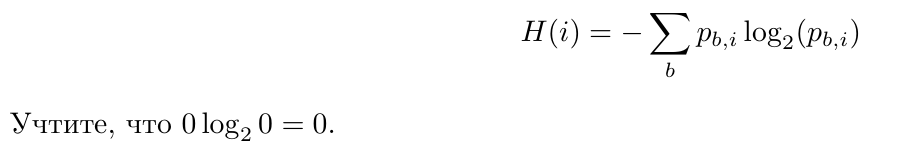

In [34]:
n = len(sites[0])
H = np.zeros(n)
for i in range(n):
    for b in range(4):
        if ppm[b, i] > 0:
            H[i] -= ppm[b, i] * np.log2(ppm[b, i])
H

array([1.60312107, 0.87576168, 1.03086909, 0.23429203, 0.23429203,
       1.44801367, 1.02532307, 0.87576168, 1.03086909])

In [35]:
IC = 2 - H
IC

array([0.39687893, 1.12423832, 0.96913091, 1.76570797, 1.76570797,
       0.55198633, 0.97467693, 1.12423832, 0.96913091])

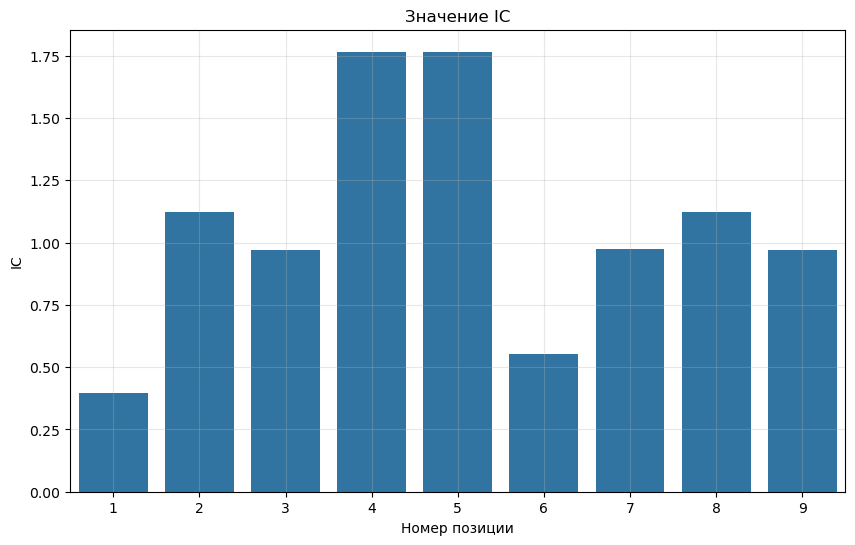

In [36]:
positions = [i for i in range(1, n+1)]

plt.figure(figsize=(10, 6))
sns.barplot(x=positions, y=IC)
plt.title('Значение IC')
plt.xlabel('Номер позиции')
plt.ylabel('IC')
plt.grid(alpha=0.3)
plt.show()

Позиции 4-5 являются "кор-мотивом" (самыми важными для связывания), у них самые высокие значения IC, то есть самая маленькая энтропия (значит, на этом месте почти всегда одна и та же буква)

Выравнивание:

In [37]:
df = pd.DataFrame([list(seq) for seq in sites])
df.columns = range(1, len(df.columns) + 1)
df

,1,2,3,4,5,6,7,8,9
0,G,A,G,G,T,A,A,A,C
1,T,C,C,G,T,A,A,G,C
2,C,A,G,G,T,T,G,G,A
3,A,C,A,G,T,C,A,G,C
4,T,A,G,G,T,C,A,G,C
5,C,A,G,G,T,C,A,G,C
6,C,A,G,G,T,C,G,A,T
7,C,A,G,G,T,C,A,G,C
8,C,A,G,G,T,C,A,G,C
9,C,A,G,G,T,T,G,G,C


Видно, что в 4 и 5 позициях нуклеотиды совпадают во всех последовательностях (значит эта позиция важна для функции), поэтому её информационное содержание большое - сходится с гистограммой